In [1]:
# model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

# visualizing
import matplotlib.pyplot as plt

# etc
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# check gpu
is_cuda = torch.cuda.is_available()
device = torch.device('cuda' if is_cuda else 'cpu')

print('Cuda Device :', device)

Cuda Device : cuda


In [3]:
# load MNIST dataset
train_data = datasets.MNIST(root = '/content/drive/MyDrive/MNIST', train = True, download = True, transform = transforms.ToTensor())
test_data = datasets.MNIST(root = '/content/drive/MyDrive/MNIST', train = False, download = True, transform = transforms.ToTensor())

print(' ')
print(len(train_data), len(test_data))

 
60000 10000


In [4]:
# check size of image
image, label = train_data[0]
print(f'Shape of image: {image.squeeze().numpy().shape}')

Shape of image: (28, 28)


In [5]:
# fix random seed number for experiment replication
torch.manual_seed(1)

In [6]:
#################### fill the codes under annotation ####################

# make mlp model
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden1=256, hidden2=64, output_dim=10):
        super(MLP, self).__init__()
        # First hidden layer: Linear -> BatchNorm -> ReLU (fill this part!)
        self.fcl1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.relu1 = nn.ReLU()

        # Second hidden layer: Linear -> BatchNorm -> ReLU (fill this part!)
        self.fcl2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.relu2 = nn.ReLU()

        # Output layer: Linear mapping to classes (fill this part!)
        self.fcl3 = nn.Linear(hidden2, output_dim)

    def forward(self, x):
        # Flatten the input: [batch_size, 1, 28, 28] (fill this part!)
        flatx = x.view(-1, 28 * 28)

        # Pass through two hidden layers (fill this part!)
        flatx = self.relu1(self.bn1(self.fcl1(flatx)))
        flatx = self.relu2(self.bn2(self.fcl2(flatx)))

        # Final output layer (fill this part!)
        flatx = self.fcl3(flatx)

        return flatx

In [7]:
# load MLP model to GPU
# set hyperparameters for training
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

In [8]:
# use data loader for training data
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_data, batch_size=256, shuffle=True)

In [9]:
#################### fill the codes under annotation ####################

# run 50 iterations of training
for epoch in range(num_epochs):
    # train model (fill this part!)
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # compute loss over epochs (fill this part!)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/50, Loss: 0.3548
Epoch 2/50, Loss: 0.0951
Epoch 3/50, Loss: 0.0559
Epoch 4/50, Loss: 0.0388
Epoch 5/50, Loss: 0.0268
Epoch 6/50, Loss: 0.0209
Epoch 7/50, Loss: 0.0154
Epoch 8/50, Loss: 0.0123
Epoch 9/50, Loss: 0.0115
Epoch 10/50, Loss: 0.0102
Epoch 11/50, Loss: 0.0111
Epoch 12/50, Loss: 0.0090
Epoch 13/50, Loss: 0.0066
Epoch 14/50, Loss: 0.0079
Epoch 15/50, Loss: 0.0077
Epoch 16/50, Loss: 0.0071
Epoch 17/50, Loss: 0.0044
Epoch 18/50, Loss: 0.0037
Epoch 19/50, Loss: 0.0048
Epoch 20/50, Loss: 0.0089
Epoch 21/50, Loss: 0.0067
Epoch 22/50, Loss: 0.0041
Epoch 23/50, Loss: 0.0015
Epoch 24/50, Loss: 0.0009
Epoch 25/50, Loss: 0.0011
Epoch 26/50, Loss: 0.0049
Epoch 27/50, Loss: 0.0118
Epoch 28/50, Loss: 0.0075
Epoch 29/50, Loss: 0.0042
Epoch 30/50, Loss: 0.0018
Epoch 31/50, Loss: 0.0009
Epoch 32/50, Loss: 0.0010
Epoch 33/50, Loss: 0.0014
Epoch 34/50, Loss: 0.0043
Epoch 35/50, Loss: 0.0051
Epoch 36/50, Loss: 0.0060
Epoch 37/50, Loss: 0.0037
Epoch 38/50, Loss: 0.0043
Epoch 39/50, Loss: 0.

In [10]:
#################### fill the codes under annotation ####################

# use data loader for test data
test_loader = DataLoader(dataset=test_data, batch_size=256, shuffle=False)

# check accuracy of the trained model (fill this part!)
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate accuracy (fill this part!)
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.36%


In [11]:
# 8bit quantization of the model
model.to('cpu')

import torch.quantization
quantized_model = torch.quantization.quantize_dynamic(
    model,              # the original model
    {nn.Linear},        # layers to quantize
    dtype=torch.qint8   # quantize to 8-bit integers
)

quantized_model.eval()
quantized_model.to('cpu')

/tmp/ipykernel_5962/200779063.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


MLP(
  (fcl1): DynamicQuantizedLinear(in_features=784, out_features=256, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (fcl2): DynamicQuantizedLinear(in_features=256, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (fcl3): DynamicQuantizedLinear(in_features=64, out_features=10, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
)

In [12]:
# check accuracy of the quantized model
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        # Ensure images are on CPU since the quantized model works on CPU
        images = images.to('cpu')
        outputs = quantized_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Quantized Model Test Accuracy: {accuracy:.2f}%")

Quantized Model Test Accuracy: 98.33%


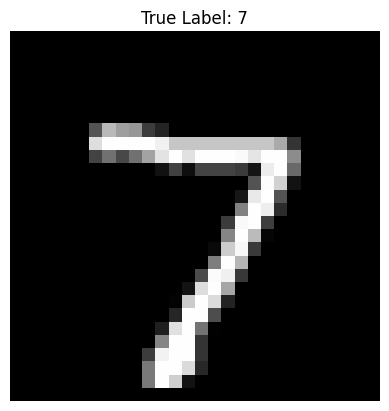

0.00% that the number is 0
0.00% that the number is 1
0.00% that the number is 2
0.00% that the number is 3
0.00% that the number is 4
0.00% that the number is 5
0.00% that the number is 6
100.00% that the number is 7
0.00% that the number is 8
0.00% that the number is 9


In [13]:
import matplotlib.pyplot as plt

# Select one test sample.
image, label = test_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {label}")
plt.axis('off')
plt.show()

# run single inference
with torch.no_grad():
    images = images.to('cpu')
    output = quantized_model(image)

# convert probabilities to a NumPy array.
probabilities = torch.softmax(output, dim=1)
probabilities_np = probabilities.cpu().numpy()[0]

# display the probability for each class as a percentage.
for digit, prob in enumerate(probabilities_np):
    print(f"{prob*100:.2f}% that the number is {digit}")

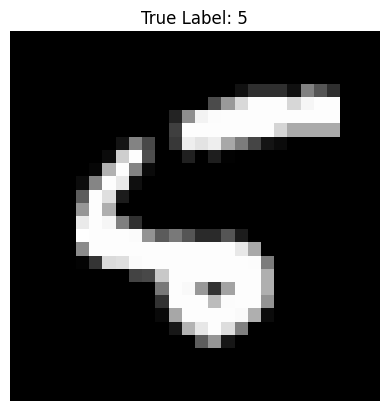

0.00% that the number is 0
0.00% that the number is 1
0.00% that the number is 2
0.00% that the number is 3
0.00% that the number is 4
99.94% that the number is 5
0.06% that the number is 6
0.00% that the number is 7
0.00% that the number is 8
0.00% that the number is 9


In [14]:
import matplotlib.pyplot as plt

# Select one test sample.
image, label = test_data[8]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {label}")
plt.axis('off')
plt.show()

# run single inference
with torch.no_grad():
    images = images.to('cpu')
    output = quantized_model(image)

# convert probabilities to a NumPy array.
probabilities = torch.softmax(output, dim=1)
probabilities_np = probabilities.cpu().numpy()[0]

# display the probability for each class as a percentage.
for digit, prob in enumerate(probabilities_np):
    print(f"{prob*100:.2f}% that the number is {digit}")